In [1]:
!pip install pandas matplotlib seaborn

In [104]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import os
import matplotlib.ticker as mticker

In [91]:
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120 
plt.rcParams["font.family"] = "sans-serif"

os.makedirs("charts",exist_ok=True)
print("=" * 55) 
print(" Agricultural Crop Production EDA — Starting")
print("=" * 55)

 Agricultural Crop Production EDA — Starting


In [92]:
print("n[1/7]Loading data...")
df = pd.read_csv(r"C:\Users\ACER\Downloads\FAOSTAT_crops.csv" ,encoding="utf-8-sig")
df.columns = df.columns.str.strip()
#print(df.columns.tolist())
print(f"Rows loaded:{len(df):,}")
print(f"Columns:{list(df.columns)}")

n[1/7]Loading data...
Rows loaded:17,634
Columns:['Domain Code', 'Domain', 'Area Code (M49)', 'Area', 'Element Code', 'Element', 'Item Code (CPC)', 'Item', 'Year Code', 'Year', 'Unit', 'Value', 'Flag', 'Flag Description', 'Note']


In [93]:
print("\n[2/7] Inspecting data...") 
print("\n--- First 5 rows ---") 
print(df.head()) 
print("\n--- Data types ---") 
print(df.dtypes) 
print("\n--- Missing values per column ---") 
print(df.isnull().sum()) 
print("\n--- Basic statistics ---") 
print(df.describe())


[2/7] Inspecting data...

--- First 5 rows ---
  Domain Code                        Domain  Area Code (M49)         Area  \
0         QCL  Crops and livestock products                4  Afghanistan   
1         QCL  Crops and livestock products                4  Afghanistan   
2         QCL  Crops and livestock products                4  Afghanistan   
3         QCL  Crops and livestock products                4  Afghanistan   
4         QCL  Crops and livestock products                4  Afghanistan   

   Element Code         Element  Item Code (CPC)          Item  Year Code  \
0          5312  Area harvested              112  Maize (corn)       2003   
1          5510      Production              112  Maize (corn)       2003   
2          5312  Area harvested              112  Maize (corn)       2004   
3          5510      Production              112  Maize (corn)       2004   
4          5312  Area harvested              112  Maize (corn)       2005   

   Year Unit     Value Fla

In [94]:
needed_cols = ["Area","Item","Element","Year","Value"]
df = df[needed_cols]
existing_cols = [c for c in needed_cols if c in df.columns]

df = df[existing_cols]
df = df.rename(columns={
    "Area":"country",
    "Item":"crop",
    "Element":"element",
    "Year":"year",
    "Value":"value"
})
df = df[df["element"] == "Production"]
rows_before = len(df)
df=df.dropna(subset=["value"])
rows_after = len(df)
print(f" Dropped {rows_before - rows_after} rows with missing values" )



 Dropped 227 rows with missing values


In [95]:
crops_of_interest = ["Wheat","Maize (corn)","Soya beans"]
df = df[df["crop"].isin(crops_of_interest)]

In [96]:
aggregate_regions = [ "World", "Africa", "Asia", "Europe", "Americas",
                      "Oceania", "Northern America", "South America",
                      "Eastern Africa", "Western Africa", "Southern Asia",
                      "Eastern Asia", "Western Europe", "Eastern Europe",
                      "Northern Europe", "Southern Europe", "Central America",
                      "Caribbean", "Melanesia", "Polynesia", "Micronesia" ]
df = df[~df["country"].isin(aggregate_regions)]

In [97]:
df["year"] = pd.to_numeric(df["year"], errors="coerce") 
df["value"] = pd.to_numeric(df["value"], errors="coerce") 
df = df.dropna(subset=["year", "value"])
df["year"] = df["year"].astype(int)

In [98]:
print(f" Final dataset: {len(df):,} rows") 
print(f" Countries: {df['country'].nunique()}") 
print(f" Crops: {df['crop'].unique()}") 
print(f" Years: {df['year'].min()} – {df['year'].max()}")

 Final dataset: 8,584 rows
 Countries: 183
 Crops: ['Maize (corn)' 'Soya beans' 'Wheat']
 Years: 2003 – 2024


In [75]:
df["element"].unique()

array(['Production'], dtype=object)

In [87]:
df["crop"].value_counts().head(20)

crop
Wheat         2751
Soya beans    2193
Name: count, dtype: int64

In [99]:
df["value_mt"] = df["value"] / 1_000_000 
print(f" Final dataset: {len(df):,} rows") 
print(f" Countries: {df['country'].nunique()}") 
print(f" Crops: {df['crop'].unique()}") 
print(f" Years: {df['year'].min()} – {df['year'].max()}")

 Final dataset: 8,584 rows
 Countries: 183
 Crops: ['Maize (corn)' 'Soya beans' 'Wheat']
 Years: 2003 – 2024



[4/7] Creating charts...
Saved: charts/01_global_trend.png


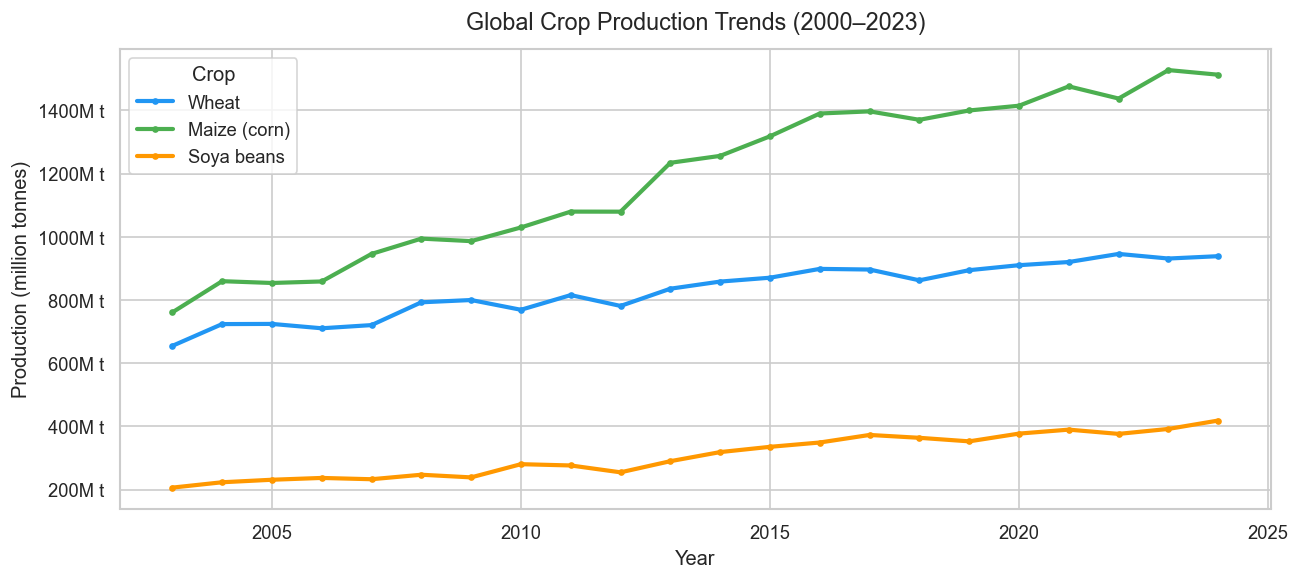

In [109]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

print("\n[4/7] Creating charts...")

yearly_global = (
    df.groupby(["year", "crop"])["value_mt"]
    .sum()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(11, 5))

for crop, color in zip(crops_of_interest, ["#2196F3", "#4CAF50", "#FF9800"]):
    subset = yearly_global[yearly_global["crop"] == crop]
    ax.plot(
        subset["year"],
        subset["value_mt"],
        label=crop,
        color=color,
        linewidth=2.5,
        marker="o",
        markersize=3
    )

ax.set_title("Global Crop Production Trends (2000–2023)", fontsize=14, pad=12)
ax.set_xlabel("Year")
ax.set_ylabel("Production (million tonnes)")
ax.legend(title="Crop")

ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x:.0f}M t")
)

plt.tight_layout()
plt.savefig("charts/01_global_trend.png")
#plt.close()

print("Saved: charts/01_global_trend.png")

 Saved: charts/02_top10_countries.png
 Saved: charts/02_top10_countries.png
 Saved: charts/02_top10_countries.png
 Saved: charts/02_top10_countries.png
 Saved: charts/02_top10_countries.png
 Saved: charts/02_top10_countries.png
 Saved: charts/02_top10_countries.png
 Saved: charts/02_top10_countries.png
 Saved: charts/02_top10_countries.png
 Saved: charts/02_top10_countries.png


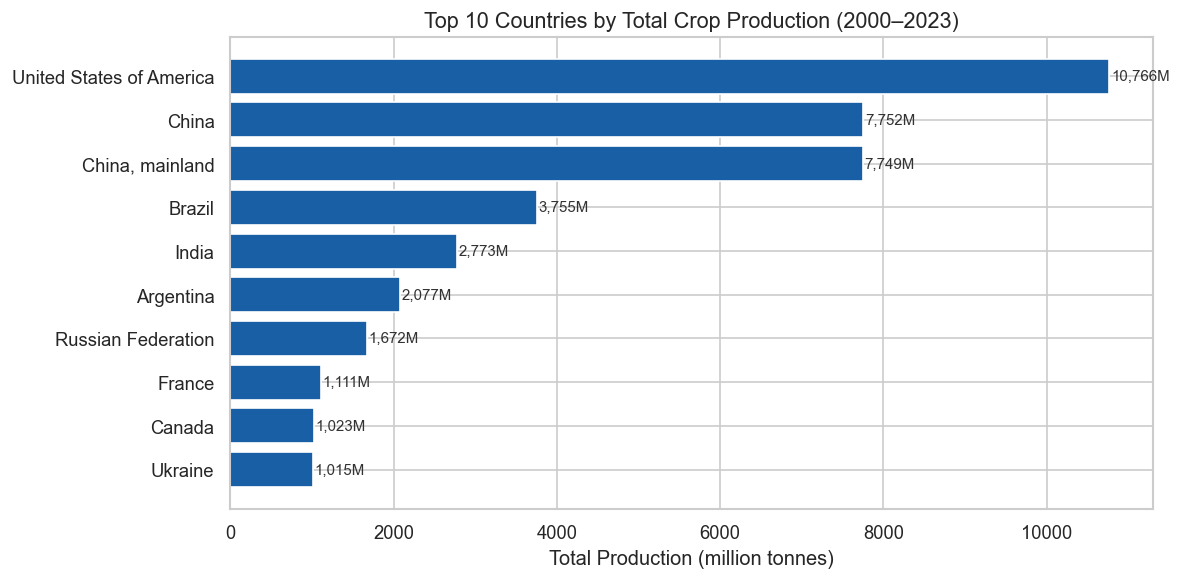

In [110]:
top10 = ( df.groupby("country")["value_mt"]
    .sum()
    .sort_values(ascending=False) 
    .head(10) 
    .reset_index() )
fig, ax = plt.subplots(figsize=(10, 5)) 
bars = ax.barh(top10["country"][::-1], 
               top10["value_mt"][::-1], 
               color="#185FA5") 
ax.set_title("Top 10 Countries by Total Crop Production (2000–2023)",
             fontsize=13) 
ax.set_xlabel("Total Production (million tonnes)") 
for bar in bars: 
    width = bar.get_width() 
    ax.text(width + 20, bar.get_y() + bar.get_height() / 2, 
            f"{width:,.0f}M", va="center", fontsize=9, color="#333")
    plt.tight_layout() 
    plt.savefig("charts/02_top10_countries.png") 
    #plt.close() 
    print(" Saved: charts/02_top10_countries.png")

 Saved: charts/03_crop_comparison.png
 Saved: charts/03_crop_comparison.png
 Saved: charts/03_crop_comparison.png


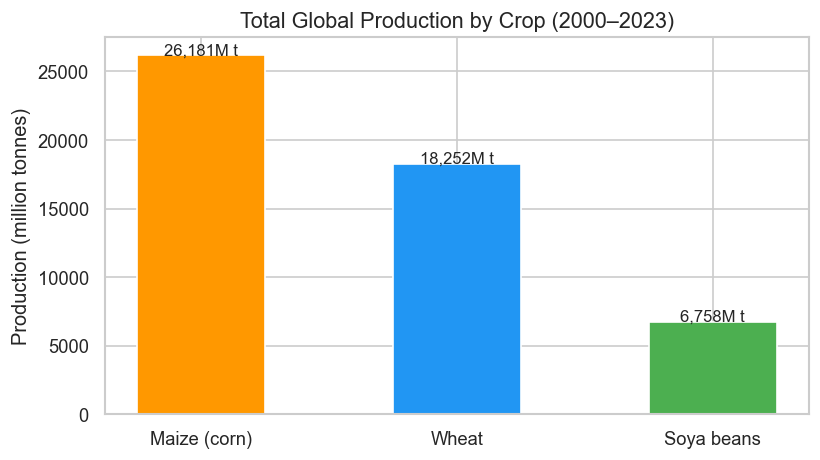

In [111]:
crop_totals = (
    df.groupby("crop")["value_mt"] .
        sum() 
        .reset_index() 
        .sort_values("value_mt", ascending=False) )
fig, ax = plt.subplots(figsize=(7, 4)) 
colors = ["#FF9800", "#2196F3", "#4CAF50"] 
bars = ax.bar(crop_totals["crop"],
              crop_totals["value_mt"], 
              color=colors, width=0.5) 
ax.set_title("Total Global Production by Crop (2000–2023)",
             fontsize=13) 
ax.set_ylabel("Production (million tonnes)") 
for bar in bars: 
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 50, 
            f"{bar.get_height():,.0f}M t", 
            ha="center",
            fontsize=10) 
    plt.tight_layout() 
    plt.savefig("charts/03_crop_comparison.png") 
    #plt.close() 
    print(" Saved: charts/03_crop_comparison.png")

 Saved: charts/04_heatmap.png


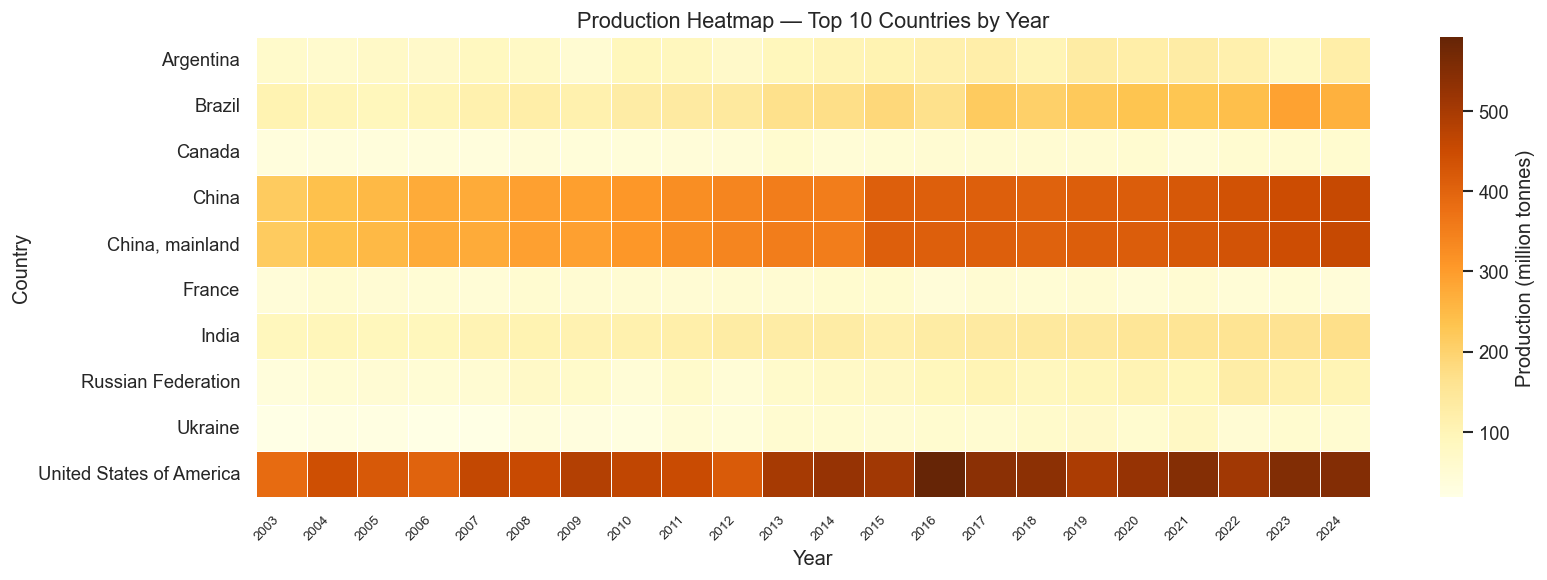

In [121]:
top10_countries = top10["country"].tolist()
heatmap_data = (
    df[df["country"].isin(top10_countries)].
    groupby(["country","year"])["value_mt"].
    sum()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(14, 5)) 
sns.heatmap( 
    heatmap_data,
    ax=ax, 
    cmap="YlOrBr", 
    linewidths=0.3,
    linecolor="white", 
    cbar_kws={"label": "Production (million tonnes)"} ) 
ax.set_title("Production Heatmap — Top 10 Countries by Year", fontsize=13) 
ax.set_xlabel("Year") 
ax.set_ylabel("Country") 
plt.xticks(rotation=45, 
ha="right", 
fontsize=8) 
plt.tight_layout() 
plt.savefig("charts/04_heatmap.png") 
#plt.close() 
print(" Saved: charts/04_heatmap.png")

 Saved: charts/05_decade_comparison.png


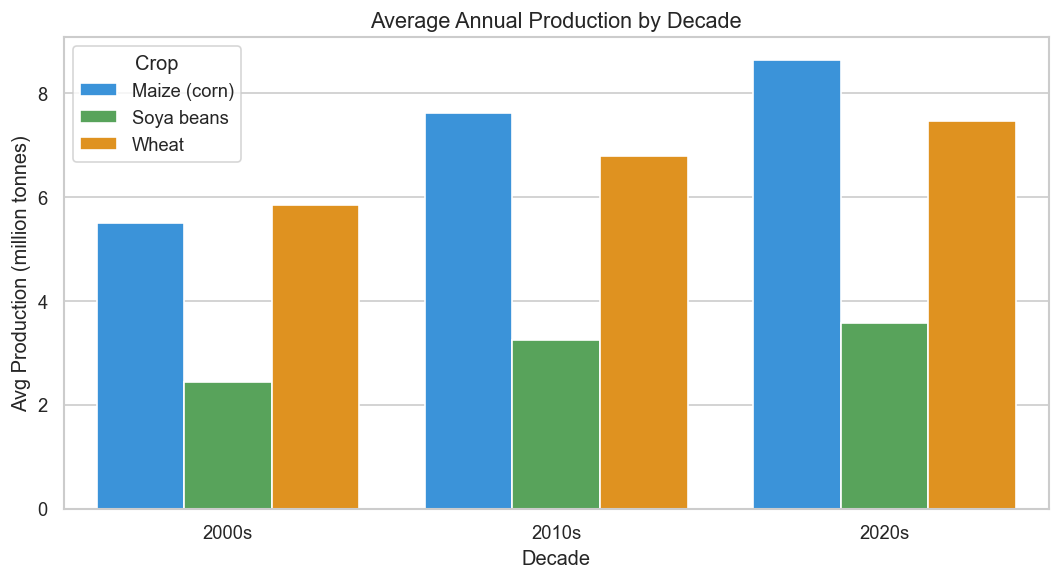

In [128]:
def get_decade(year): 
    if year < 2010: 
        return "2000s" 
    elif year < 2020: 
        return "2010s" 
    else: 
        return "2020s"
df["decade"] = df["year"].apply(get_decade)

decade_crop =( 
    df.groupby(["decade", "crop"])["value_mt"] 
    .mean() 
    .reset_index() )
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot( 
    data=decade_crop, 
    x="decade", y="value_mt", hue="crop", 
    palette=["#2196F3", "#4CAF50", "#FF9800"], 
    ax=ax )
ax.set_title("Average Annual Production by Decade", fontsize=13)
ax.set_xlabel("Decade") 
ax.set_ylabel("Avg Production (million tonnes)") 
ax.legend(title="Crop") 
plt.tight_layout() 
plt.savefig("charts/05_decade_comparison.png") 
#plt.close() 
print(" Saved: charts/05_decade_comparison.png")

In [132]:
print("\n[5/7] Generating summary statistics...") 
print("\n" + "=" * 55) 
print(" KEY FINDINGS")
print("=" * 55)
for crop in crops_of_interest: 
    crop_df = df[df["crop"] == crop] 
    early = crop_df[crop_df["year"] <= 2005]["value_mt"].sum() 
    late = crop_df[crop_df["year"] >= 2018]["value_mt"].sum() 
    growth = ((late - early) / early) * 100 if early > 0 else 0 
    top_country = (crop_df.groupby("country")["value_mt"] .sum().idxmax()) 
    total = crop_df["value_mt"].sum() 
    print(f"\n {crop}:") 
    print(f" Total production (2000-2023): {total:,.0f} million tonnes")
    print(f" Top producing country: {top_country}") 
    print(f" Production growth (early 2000s vs 2018+): {growth:+.1f}%")


[5/7] Generating summary statistics...

 KEY FINDINGS

 Wheat:
 Total production (2000-2023): 18,252 million tonnes
 Top producing country: China
 Production growth (early 2000s vs 2018+): +204.5%

 Maize (corn):
 Total production (2000-2023): 26,181 million tonnes
 Top producing country: United States of America
 Production growth (early 2000s vs 2018+): +309.9%

 Soya beans:
 Total production (2000-2023): 6,758 million tonnes
 Top producing country: United States of America
 Production growth (early 2000s vs 2018+): +304.5%


In [133]:
yearly_total = df.groupby("year")["value_mt"].sum() 
best_year = yearly_total.idxmax() 
print(f"\n Best year for global crop production: {best_year}") 
print(f" Total: {yearly_total[best_year]:,.0f} million tonnes")


 Best year for global crop production: 2024
 Total: 2,870 million tonnes


In [134]:
print("\n[6/7] Saving clean dataset...") 
df.to_csv("FAOSTAT_crops_clean.csv", index=False) 
print(" Saved: FAOSTAT_crops_clean.csv") 
print("\n[7/7] Done!") 
print("\nAll charts saved in the 'charts/' folder.") 
print("Open them to see your analysis results.")
print("=" * 55) 


[6/7] Saving clean dataset...
 Saved: FAOSTAT_crops_clean.csv

[7/7] Done!

All charts saved in the 'charts/' folder.
Open them to see your analysis results.
